# 01b - NiHSA 2026 Flood Risk Communities

Explores the NiHSA 2026 at-risk communities dataset (`AFO_communities_atrisk_2026.csv`), which identifies ~30,700 communities across Nigeria at risk of flooding in the 2026 season. Each community is attributed with an estimated flood depth (`depth_m`) and a categorical depth zone (Low / Medium / High).

Analysis covers:
- Distribution of flood depth by zone
- State-level breakdown of at-risk communities
- Geographic coverage relative to the selected LGAs in the Niger-Benue intervention zone

In [1]:
import ocha_stratus as stratus
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import numpy as np
from matplotlib.patches import Patch

load_dotenv()

True

## Load data

In [2]:
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
df_risk = stratus.load_csv_from_blob("ds-aa-nga-flooding/raw/AA-nigeria_data/NiHSA/AFO_communities_atrisk_2026.csv")

## Depth analysis

In [3]:
# Normalise depth_zone capitalisation
df_risk = df_risk.copy()
df_risk["depth_zone"] = df_risk["depth_zone"].str.strip().str.capitalize()

ZONE_ORDER  = ["Low", "Medium", "High"]
ZONE_COLORS = {"Low": "#4A90E2", "Medium": "#F77F00", "High": "#E63946"}

print(f"Communities at risk: {len(df_risk):,}")
print(f"States: {df_risk['state'].nunique()}  |  LGAs: {df_risk['lga'].nunique()}")
print()
print("Depth zone breakdown:")
for z in ZONE_ORDER:
    sub = df_risk[df_risk["depth_zone"] == z]
    print(f"  {z:8s}: {len(sub):6,} communities  "
          f"depth {sub['depth_m'].min():.2f}–{sub['depth_m'].max():.2f} m  "
          f"(mean {sub['depth_m'].mean():.2f} m)")
print()
print("Note: population column contains all zeros — excluded from analysis.")

Communities at risk: 30,707
States: 37  |  LGAs: 508

Depth zone breakdown:
  Low     :    923 communities  depth 0.11–0.48 m  (mean 0.32 m)
  Medium  : 25,552 communities  depth 0.50–1.99 m  (mean 1.00 m)
  High    :  4,232 communities  depth 2.00–5.24 m  (mean 3.05 m)

Note: population column contains all zeros — excluded from analysis.


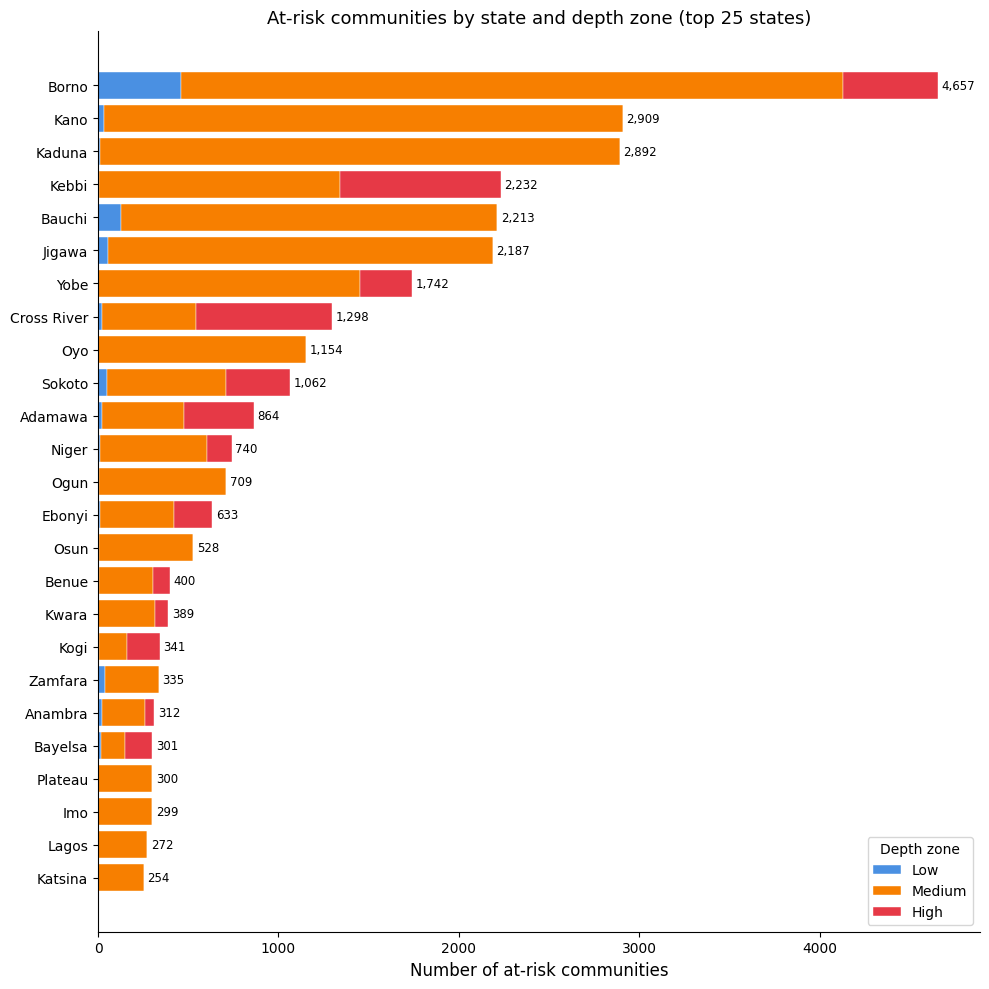

In [4]:
# --- State-level breakdown ---
state_zone = (
    df_risk.groupby(["state", "depth_zone"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ZONE_ORDER, fill_value=0)
)
state_zone["total"] = state_zone.sum(axis=1)
state_zone = state_zone.sort_values("total", ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(10, 10))
left = np.zeros(len(state_zone))
for zone in ZONE_ORDER:
    vals = state_zone[zone].values
    bars = ax.barh(state_zone.index, vals, left=left,
                   color=ZONE_COLORS[zone], label=zone,
                   edgecolor="white", linewidth=0.3)
    left += vals

# Total count labels
for i, (_, row) in enumerate(state_zone.iterrows()):
    ax.text(row["total"] + 20, i, f"{row['total']:,}",
            va="center", fontsize=8.5)

ax.set_xlabel("Number of at-risk communities", fontsize=12)
ax.set_title("At-risk communities by state and depth zone (top 25 states)", fontsize=13)
ax.legend(title="Depth zone", fontsize=10, title_fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/nihsa_state_breakdown.png", dpi=200, bbox_inches="tight")

## LGA selection coverage

In [5]:
# --- Spatial join: identify communities within selected LGAs ---
gdf_risk = gpd.GeoDataFrame(
    df_risk,
    geometry=gpd.points_from_xy(df_risk["lon"], df_risk["lat"]),
    crs="EPSG:4326",
)

_matched = gpd.sjoin(
    gdf_risk, gdf_lga_sel[["geometry"]], how="inner", predicate="within"
).index.unique()
gdf_risk["in_selected_lga"] = gdf_risk.index.isin(_matched)

n_in = gdf_risk["in_selected_lga"].sum()
n_total = len(gdf_risk)
print(f"Communities in selected LGAs: {n_in:,} / {n_total:,} ({n_in / n_total * 100:.1f}%)")
print()
print("By depth zone:")
for z in ZONE_ORDER:
    sub = gdf_risk[gdf_risk["depth_zone"] == z]
    n_in_z = sub["in_selected_lga"].sum()
    print(f"  {z:8s}: {n_in_z:,} / {len(sub):,} ({n_in_z / len(sub) * 100:.1f}%) in selected LGAs")

NameError: name 'gdf_lga_sel' is not defined

## Maps

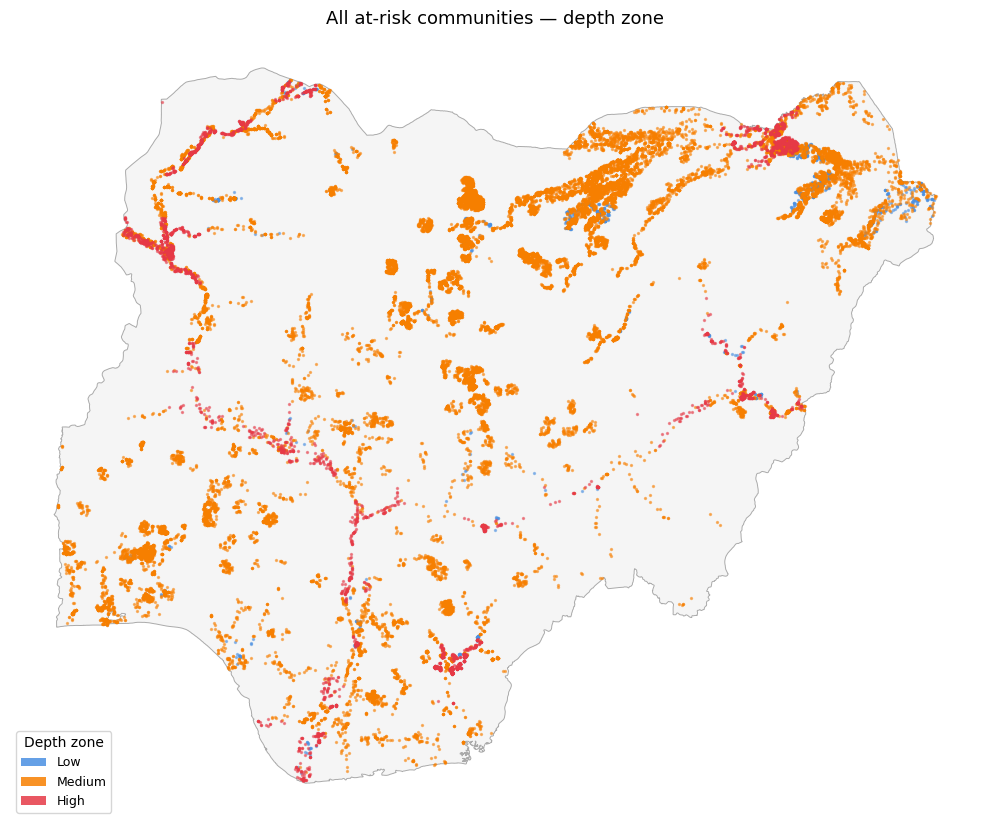

In [ ]:
# --- Map: all communities coloured by depth_zone ---
fig, ax = plt.subplots(figsize=(10, 9))

gdf_codab.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.7)

for zone in ZONE_ORDER:
    sub = gdf_risk[gdf_risk["depth_zone"] == zone]
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=2, alpha=0.5, zorder=3)

legend_handles = [Patch(facecolor=ZONE_COLORS[z], alpha=0.85, label=z) for z in ZONE_ORDER]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, title="Depth zone")
ax.set_title("All at-risk communities — depth zone", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("figures/nihsa_community_map_zones_all.png", dpi=300, bbox_inches="tight")

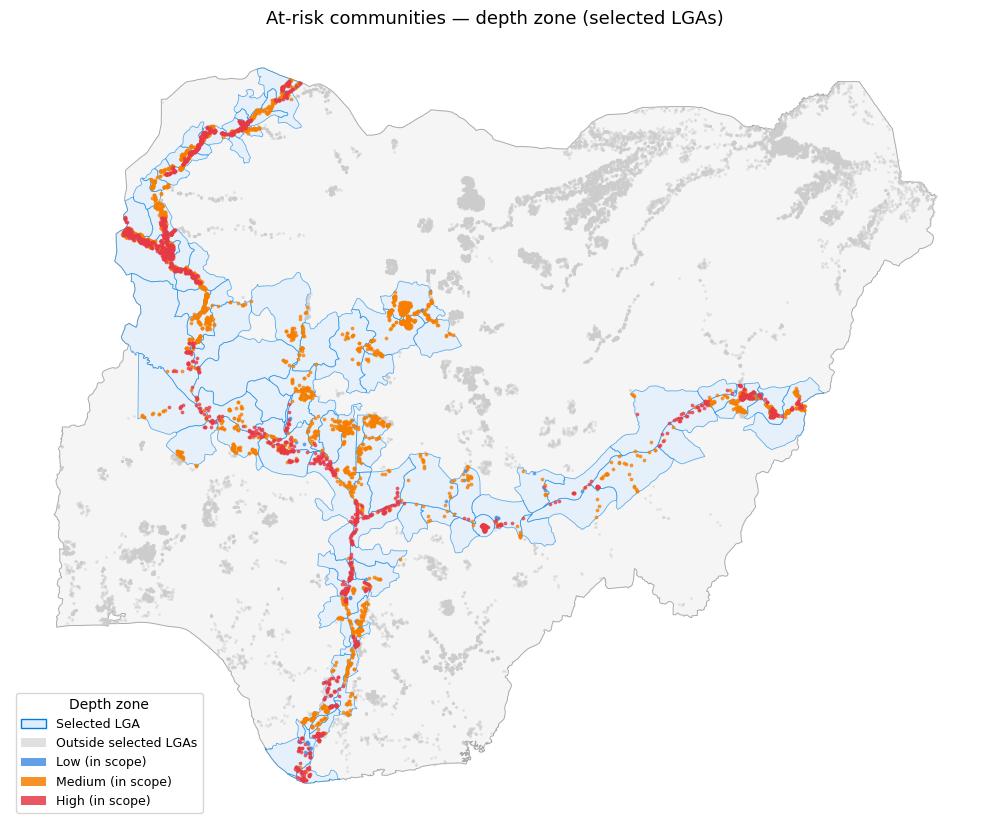

In [ ]:
# --- Map: communities coloured by depth_zone, selected LGAs highlighted ---
fig, ax = plt.subplots(figsize=(10, 9))

gdf_codab.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.7)
gdf_lga_sel.plot(ax=ax, facecolor="#dceeff", edgecolor="#007CE0", linewidth=0.6, alpha=0.6, zorder=2)

gdf_risk[~gdf_risk["in_selected_lga"]].plot(
    ax=ax, color="#cccccc", markersize=1.5, alpha=0.3, zorder=3
)
for zone in ZONE_ORDER:
    sub = gdf_risk[gdf_risk["in_selected_lga"] & (gdf_risk["depth_zone"] == zone)]
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=3, alpha=0.7, zorder=4)

legend_handles = [
    Patch(facecolor="#dceeff", edgecolor="#007CE0", label="Selected LGA"),
    Patch(facecolor="#cccccc", alpha=0.6, label="Outside selected LGAs"),
] + [Patch(facecolor=ZONE_COLORS[z], alpha=0.85, label=f"{z} (in scope)") for z in ZONE_ORDER]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, title="Depth zone")
ax.set_title("At-risk communities — depth zone (selected LGAs)", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("figures/nihsa_community_map_zones_sel.png", dpi=300, bbox_inches="tight")

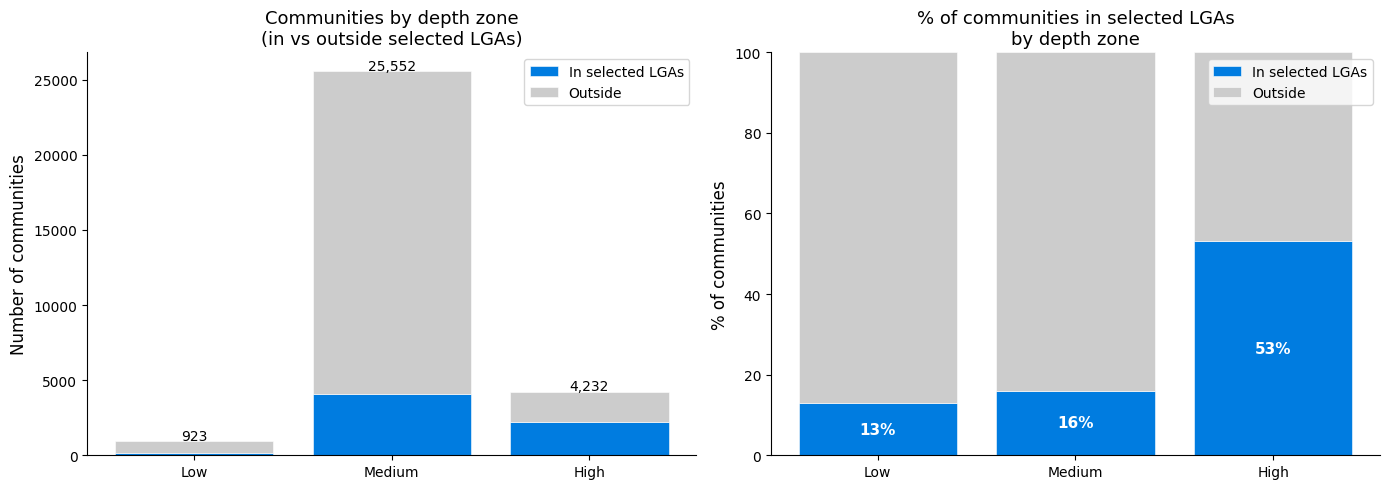

In [ ]:
# --- Selection coverage by depth zone ---
records = []
for z in ZONE_ORDER:
    sub = gdf_risk[gdf_risk["depth_zone"] == z]
    n_in  = sub["in_selected_lga"].sum()
    n_out = len(sub) - n_in
    records.append({"zone": z, "In selected LGAs": n_in, "Outside": n_out, "total": len(sub)})
df_sel = pd.DataFrame(records).set_index("zone")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
ax = axes[0]
left = np.zeros(len(df_sel))
for label, color in [("In selected LGAs", "#007CE0"), ("Outside", "#cccccc")]:
    vals = df_sel[label].values
    bars = ax.bar(df_sel.index, vals, bottom=left, color=color, label=label,
                  edgecolor="white", linewidth=0.4)
    left += vals
for i, (_, row) in enumerate(df_sel.iterrows()):
    ax.text(i, row["total"] + 80, f"{row['total']:,}", ha="center", fontsize=10)
ax.set_ylabel("Number of communities", fontsize=12)
ax.set_title("Communities by depth zone\n(in vs outside selected LGAs)", fontsize=13)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Right: percentage inside selected LGAs
ax = axes[1]
pct_in  = df_sel["In selected LGAs"] / df_sel["total"] * 100
pct_out = 100 - pct_in
left = np.zeros(len(df_sel))
for label, vals, color in [
    ("In selected LGAs", pct_in.values,  "#007CE0"),
    ("Outside",          pct_out.values, "#cccccc"),
]:
    ax.bar(df_sel.index, vals, bottom=left, color=color, label=label,
           edgecolor="white", linewidth=0.4)
    left += vals
for i, pct in enumerate(pct_in):
    ax.text(i, pct / 2, f"{pct:.0f}%", ha="center", va="center",
            color="white", fontsize=11, fontweight="bold")
ax.set_ylabel("% of communities", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title("% of communities in selected LGAs\nby depth zone", fontsize=13)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/nihsa_selection_by_zone.png", dpi=300, bbox_inches="tight")

In [6]:
adm2 = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

df_at_risk_lga = (
    df_risk.groupby(["state", "lga"])
    .size()
    .reset_index(name="at_risk_communities")
)
df_at_risk_lga["state"] = df_at_risk_lga["state"].str.strip().str.title()
df_at_risk_lga["lga"] = df_at_risk_lga["lga"].str.strip().str.title()

df_at_risk_pcode = (
    adm2[["ADM2_PCODE", "ADM1_EN", "ADM2_EN"]]
    .merge(df_at_risk_lga, left_on=["ADM1_EN", "ADM2_EN"], right_on=["state", "lga"], how="left")
    [["ADM2_PCODE", "at_risk_communities"]]
)

stratus.upload_parquet_to_blob(
    df_at_risk_pcode,
    "ds-aa-nga-flooding/processed/web_map/at_risk_communities.parquet",
)